# Universal Grammar Generative Model

In [1]:
INSTALL = false

if INSTALL
    using Pkg
    Pkg.add("StatsPlots"); using StatsPlots
    Pkg.add("StatsBase")
    Pkg.activate("psyc261")
    Pkg.add(["JLD2", "Distributions", "ProgressMeter", "Parameters", 
            "Random", "Gen", "Plots", "PyCall", "Conda", "JSON3"])
end

In [2]:
using Pkg
Pkg.activate("psyc261")
using JLD2
using Distributions
using Distributions: TruncatedNormal
using ProgressMeter
using Parameters
using Random
using StatsPlots
using Gen, Plots
using PyCall
np = pyimport("numpy")

include("../src/ug_model.jl")
using .UGmodel

  Activating project at `~/Algorithms-of-the-Mind/aom/notebooks/psyc261`


In [3]:
# Lexicon constants
const NOUNS = UGmodel.LEXICON.nouns
const VERBS_TRANS = UGmodel.LEXICON.verbs_trans
const VERBS_INTR = UGmodel.LEXICON.verbs_intr
const ADJECTIVES = UGmodel.LEXICON.adjectives
const WH_WORD = UGmodel.LEXICON.wh_word
const COMPL = UGmodel.LEXICON.complementizer

# Vocab construction
const VOCAB = unique(vcat(["PAD", WH_WORD, COMPL], NOUNS, VERBS_TRANS, VERBS_INTR, ADJECTIVES))
const VOCAB_SIZE = length(VOCAB)
const WORD_TO_IDX = Dict(w => i for (i,w) in enumerate(VOCAB))
const MAX_SENT_LEN = 12

# IDs for vocab
const NOUN_IDS = [WORD_TO_IDX[w] for w in NOUNS]
const VERB_TRANS_IDS = [WORD_TO_IDX[w] for w in VERBS_TRANS]
const VERB_INTR_IDS = [WORD_TO_IDX[w] for w in VERBS_INTR]
const ADJ_IDS = [WORD_TO_IDX[w] for w in ADJECTIVES]
const WH_ID = WORD_TO_IDX[WH_WORD]
const COMPL_ID = WORD_TO_IDX[COMPL]
const PAD_ID = WORD_TO_IDX["PAD"]

# Soft alignment consts and helper functions
function compute_alignment_weights(len::Int, σ::Float64)
    weights = zeros(Float64, len, len)
    for obs_pos in 1:len
        for clause_pos in 1:len
            weights[obs_pos, clause_pos] = exp(-(obs_pos - clause_pos)^2 / (2 * σ^2))
        end
    end
    return weights
end

const SIGMA_ALIGN = 0.5
const ALIGNMENT_WEIGHTS = compute_alignment_weights(MAX_SENT_LEN, SIGMA_ALIGN)

# Helper to define all langs
function all_language_types()
    languages = NamedTuple[]
    for hd in [false, true]
        for sd in [false, true]
            for ao in [false, true]
                for wh in [false, true]
                    push!(languages, (hd=hd, sd=sd, ao=ao, wh=wh))
                end
            end
        end
    end
    return languages
end

const ALL_LANGUAGES = all_language_types()

# Math helpers
σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

# Other helpers
# Maps vectors of IDs back to vectors of Strings
function decode_sentences(sentences_ids)
    decoded = Vector{Vector{String}}()
    for sent_ids in sentences_ids
        push!(decoded, [VOCAB[idx] for idx in sent_ids])
    end
    return decoded
end

decode_sentences (generic function with 1 method)

# Generative Model

To model the Principles & Parameters prior, we are using the following UG parameters:

- Head directionality: in this case, we're using it to control whether the verb or the object will come first
- Subject drop: whether the subject of a sentence has to be kept explicit or if it can be dropped and understood from the context
- Adjective order: whether the noun or the adjective comes first
- Wh-fronting: in a Wh- question (what, who, which etc.), does the wh- word stay in its place (in-situ) or does it go to the front of the sentence

We then make the distinction for three different types of utterances: 
1. Transitive declarative: a phrase containing a subject, transitive verb, and its object in a declarative manner (no wh- word)
2. Intransitive: a phrase containing a subject and an intransitive verb
3. Transitive question: a phrase containing a subject, transitive verb, its object and a wh- word that can be fronted or not

We establish Bernoulli priors over each one of the parameters, and also a small chance that they might "slip" and occasionally be flipped in a given sentence. Although this is not the case for human languages, it suffices as a means to test our hypothesis.

The final sentence is then produced taking into account the noisy parameters and emission probability.

To construct the sentence, the model follows a hierarchical process:

1.  Recursive Noun Phrases (NP): It builds NPs using the `make_np` helper. This allows for recursion via relative clauses (e.g., "The dog [that bit the cat]..."), which is a fundamental property of human language.
2.  Verb Phrases (VP): It combines the verb and the object, respecting the Head Direction parameter (VO vs. OV).
3.  Clause Construction: Finally, it assembles the Subject and VP, applying Subject Drop and handling Wh-movement (checking if the wh- word moves to the front or stays in-situ).

### Emission and Noise Model

To make the learning task realistic, we introduce two types of noise:
1.  **Parameter Slip:** Occasionally, a speaker may "slip" and use the wrong parameter setting (e.g., producing an OV sentence in a VO language).
2.  **Soft Alignment:** We allow for "jitter" in word positioning. The `SoftAlignedEmission` distribution models the observation that words are not always heard in perfect lock-step indices. It calculates the probability of observing a token based on a Gaussian window around the expected position in the clause.

In [4]:
const NOISE_PROB = 0.1

function emission_probs(target_idx::Int; V::Int = VOCAB_SIZE, epsilon::Float64 = 0.05)
    @assert 0 < epsilon < 1
    probs = fill(epsilon / (V-1), V)
    probs[target_idx] = 1.0 -epsilon
    return probs
end

const EMISSION_CACHE = [emission_probs(i) for i in 1:VOCAB_SIZE]

13-element Vector{Vector{Float64}}:
 [0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166

In [5]:
struct SoftAlignedEmission <: Gen.Distribution{Int} end
const soft_emission = SoftAlignedEmission()

function Gen.logpdf(::SoftAlignedEmission, obs_token::Int, clause::Vector{Int}, obs_pos::Int, σ::Float64)
    prob = 0.0
    total_weight = 0.0
    n_clause = length(clause)
    
    # 1. Iterate over actual clause words using pre-calculated weights
    for clause_pos in 1:n_clause
        weight = ALIGNMENT_WEIGHTS[obs_pos, clause_pos]
        total_weight += weight
        
        clause_token = clause[clause_pos]
        emit_prob = EMISSION_CACHE[clause_token][obs_token]
        prob += weight * emit_prob
    end
    
    # 2. Handle PAD region
    for pad_pos in (n_clause+1):MAX_SENT_LEN
        weight = ALIGNMENT_WEIGHTS[obs_pos, pad_pos]
        total_weight += weight
        prob += weight * EMISSION_CACHE[PAD_ID][obs_token]
    end
    
    prob /= total_weight
    return log(prob + 1e-10)
end

function Gen.random(::SoftAlignedEmission, clause::Vector{Int}, obs_pos::Int, σ::Float64)
    # Sample using pre-calculated weights row
    weights = ALIGNMENT_WEIGHTS[obs_pos, :]
    weights ./= sum(weights)
    
    clause_pos = rand(Categorical(weights))
    token_id = clause_pos <= length(clause) ? clause[clause_pos] : PAD_ID
    
    return rand(Categorical(EMISSION_CACHE[token_id]))
end

Gen.has_output_grad(::SoftAlignedEmission) = false
Gen.has_argument_grads(::SoftAlignedEmission) = (false, false, false)

In [6]:
@gen function sentence_kernel(step::Int, state::NamedTuple, noise_enabled::Bool)
    # Extract grammar parameters
    hd = state.hd
    sd = state.sd
    ao = state.ao
    wh = state.wh
    
    if noise_enabled
        ao_slip = @trace(bernoulli(NOISE_PROB), :ao_slip)
        hd_slip = @trace(bernoulli(NOISE_PROB), :hd_slip)
        sd_slip = @trace(bernoulli(NOISE_PROB), :sd_slip)
        
        effective_ao = ao_slip ? !ao : ao
        effective_hd = hd_slip ? !hd : hd
        effective_sd = sd_slip ? !sd : sd
    else
        # Deterministic (Clean Model)
        effective_ao = ao
        effective_hd = hd
        effective_sd = sd
    end

    # Structural decisions
    is_embedded = @trace(bernoulli(0.3), :is_embedded)
    utt_type = @trace(categorical([0.4, 0.3, 0.3]), :utt_type) 

    # Lexical selection
    subj_id = NOUN_IDS[@trace(categorical(fill(1/length(NOUNS), length(NOUNS))), :subj)]
    obj_id = NOUN_IDS[@trace(categorical(fill(1/length(NOUNS), length(NOUNS))), :obj)]
    adj_id = ADJ_IDS[@trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), :adj)]

    function make_np(noun, adj, adj_order_first, head_direction_first, allow_rel_clause, addr_key)
        base_np = adj_order_first ? [adj, noun] : [noun, adj]
        
        if allow_rel_clause && is_embedded
            rel_v_idx = @trace(categorical(fill(1/length(VERB_INTR_IDS), length(VERB_INTR_IDS))), addr_key)
            rel_verb = VERB_INTR_IDS[rel_v_idx]
            rel_phrase = head_direction_first ? [COMPL_ID, rel_verb] : [rel_verb, COMPL_ID]
            return head_direction_first ? vcat(base_np, rel_phrase) : vcat(rel_phrase, base_np)
        else
            return base_np
        end
    end

    # Phrase Construction
    subj_np = make_np(subj_id, adj_id, effective_ao, effective_hd, true, :rel_verb_subj)
    obj_np = make_np(obj_id, adj_id, effective_ao, effective_hd, true, :rel_verb_obj)

    # Verb Selection & VP Construction
    vp = Vector{Int}()
    verb_id = 0
    
    if utt_type == 1 || utt_type == 3
        v_idx = @trace(categorical(fill(1/length(VERB_TRANS_IDS), length(VERB_TRANS_IDS))), :v_trans)
        verb_id = VERB_TRANS_IDS[v_idx]
        vp = (effective_hd) ? vcat([verb_id], obj_np) : vcat(obj_np, [verb_id])
    else
        v_idx = @trace(categorical(fill(1/length(VERB_INTR_IDS), length(VERB_INTR_IDS))), :v_intr)
        verb_id = VERB_INTR_IDS[v_idx]
        vp = [verb_id]
    end

    # Subject Drop
    drop_subj = (effective_sd) ? @trace(bernoulli(0.5), :drop_subj) : false

    clause = Vector{Int}()
    if !drop_subj
        append!(clause, subj_np)
    end
    append!(clause, vp)

    # Wh-fronting Logic
    if utt_type == 3
        if noise_enabled
            wh_slip = @trace(bernoulli(NOISE_PROB), :wh_slip)
            effective_wh = wh_slip ? !wh : wh
        else
            effective_wh = wh
        end
        
        if effective_wh
            pushfirst!(clause, WH_ID)
        else
            push!(clause, WH_ID)
        end
    end

    # Emission with Soft Alignment
    padded_clause = vcat(clause, fill(PAD_ID, MAX_SENT_LEN - length(clause)))
    for pos in 1:MAX_SENT_LEN
        @trace(soft_emission(padded_clause, pos, SIGMA_ALIGN), (:token, pos))
    end

    return (hd=hd, sd=sd, ao=ao, wh=wh, clause=clause)
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64, NamedTuple, Bool], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], var"##sentence_kernel#292", Bool[0, 0, 0], false)

### The Corpus Prior

While sentence_kernel generates a single noisy utterance, this function defines the generative model for the entire dataset (the "Language"). 

It samples the True Grammar $\theta$ (the four binary parameters) once, and then generates a batch of $N$ sentences based on that specific grammar. This models the linguistic environment the learner observes.

In [7]:
const sentences_unfold = Gen.Unfold(sentence_kernel)

@gen function corpus_model(num_sentences::Int, noise_enabled::Bool)
    if noise_enabled
        # Noisy Mode (Evolution/Training): Sample probabilities, then parameters
        p_hd = @trace(uniform(0.0, 1.0), :p_hd)
        p_sd = @trace(uniform(0.0, 1.0), :p_sd)
        p_ao = @trace(uniform(0.0, 1.0), :p_ao)
        p_wh = @trace(uniform(0.0, 1.0), :p_wh)
        
        hd = @trace(bernoulli(p_hd), :hd)
        sd = @trace(bernoulli(p_sd), :sd)
        ao = @trace(bernoulli(p_ao), :ao)
        wh = @trace(bernoulli(p_wh), :wh)
    else
        # Clean Mode (Development/SMC): Parameters are just uniform Booleans
        hd = @trace(bernoulli(0.5), :hd)
        sd = @trace(bernoulli(0.5), :sd)
        ao = @trace(bernoulli(0.5), :ao)
        wh = @trace(bernoulli(0.5), :wh)
    end

    init_state = (hd=hd, sd=sd, ao=ao, wh=wh, clause=Int[])
    results = @trace(sentences_unfold(num_sentences, init_state, noise_enabled), :corpus)
    return [r.clause for r in results]
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64, Bool], false, Union{Nothing, Some{Any}}[nothing, nothing], var"##corpus_model#293", Bool[0, 0], false)

We can generate a sample from our generative model. The trace contains the parameters used, and then the generated sentences.

In [8]:
trace = simulate(corpus_model, (10, true))
sentences_ids = get_retval(trace)

theta = (
    hd = trace[:hd],
    sd = trace[:sd],
    ao = trace[:ao],
    wh = trace[:wh]
)
println("Theta: ", theta)

probs = (
    p_hd = trace[:p_hd],
    p_sd = trace[:p_sd],
    p_ao = trace[:p_ao],
    p_wh = trace[:p_wh]
)
println("Probabilities: ", probs)

sentences_words = decode_sentences(sentences_ids)

for (i, sent) in enumerate(sentences_words)
    println("Sentence $i: ", sent)
end

Theta: (hd = false, sd = false, ao = false, wh = true)
Probabilities: (p_hd = 0.244991800920914, p_sd = 0.1303180329107051, p_ao = 0.3350424969029979, p_wh = 0.35750646625769344)
Sentence 1: ["dog", "small", "fox", "small", "attack"]
Sentence 2: ["big", "dog", "sleep"]
Sentence 3: ["what", "cat", "small", "that", "sleep", "chase", "cat", "small", "that", "run"]
Sentence 4: ["run", "that", "small", "fox", "sleep"]
Sentence 5: ["sleep", "that", "dog", "small", "sleep"]
Sentence 6: ["cat", "small", "sleep"]
Sentence 7: ["dog", "big", "that", "run", "sleep"]
Sentence 8: ["fox", "small", "dog", "small", "see"]
Sentence 9: ["run", "that", "fox", "big", "run", "that", "dog", "big", "attack"]
Sentence 10: ["cat", "big", "run"]


# Neural Network (Amortized Inference)

Here we define the "Innate Solver," a neural network designed to act as a fast heuristic guide for the probabilistic model.

* Architecture: A simple feed-forward network with one hidden layer ($H=128$).
* Goal: It takes a sequence of sentences (one-hot encoded) and predicts the probability of each grammar parameter (Head Direction, Subject Drop, etc.).
* Amortization: Instead of performing expensive Bayesian computation from scratch for every new language, we train this network to instantly "guess" the parameters, which we will later use to initialize our particle filter.

In [9]:
const NUM_SENTS_TRAIN = 15
const EMBED_DIM = 4
const H = 128
const SENT_FEAT_DIM = MAX_SENT_LEN * EMBED_DIM

@gen function innate_solver(token_indices::Vector{Int})
    @param E::Matrix{Float64} 
    @param W1::Matrix{Float64}
    @param b1::Vector{Float64}
    @param W2::Matrix{Float64}
    @param b2::Vector{Float64}

    num_tokens_total = length(token_indices)
    num_sents = div(num_tokens_total, MAX_SENT_LEN)
    
    hidden_sum = zeros(Float64, H)

    # Manual Feed-Forward Network Pass
    # We sum hidden states across all sentences to aggregate context
    for s in 1:num_sents
        start_idx = (s - 1) * MAX_SENT_LEN + 1
        end_idx = s * MAX_SENT_LEN
        sent_tokens = token_indices[start_idx:end_idx]
        
        sent_embedded = vec(E[:, sent_tokens])
        
        hidden_sum += W1 * sent_embedded
    end

    hidden_layer = tanh.(hidden_sum + b1)
    
    output = W2 * hidden_layer + b2
    probs = sigmoid(output)

    # We don't just return probabilities. We sample from them 
    # so that Gen can track the gradients for these choices during training.
    for i in 1:4
        @trace(Gen.bernoulli(probs[i]), (:param, i))
    end
    
    return probs
end

init_weight(out, inc) = randn(out, inc) * 0.01
init_param!(innate_solver, :E, randn(EMBED_DIM, VOCAB_SIZE) * 0.01)
init_param!(innate_solver, :W1, init_weight(H, SENT_FEAT_DIM))
init_param!(innate_solver, :b1, zeros(H))
init_param!(innate_solver, :W2, init_weight(4, H))
init_param!(innate_solver, :b2, zeros(4))

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

In [10]:
function predict_nn(input_vec::Vector{Int}, params)
    num_tokens_total = length(input_vec)
    num_sents = div(num_tokens_total, MAX_SENT_LEN)
    
    hidden_sum = zeros(Float64, length(params.b1))
    
    for s in 1:num_sents
        start_idx = (s - 1) * MAX_SENT_LEN + 1
        end_idx = s * MAX_SENT_LEN
        sent_tokens = input_vec[start_idx:end_idx]
        
        sent_embedded = vec(params.E[:, sent_tokens])
        hidden_sum += params.W1 * sent_embedded
    end

    hidden = tanh.(hidden_sum + params.b1)
    output = params.W2 * hidden + params.b2
    probs = sigmoid(output)

    return probs
end

predict_nn (generic function with 1 method)

In [11]:
const TRAIN_MODEL = true
const PARAMS_FILE = "innate_solver_params.jld2"
const NUM_EPOCHS = 500
const EPOCH_SIZE = 50
const LEARNING_RATE = 0.001

function encode_corpus(sentences, num_sents)
    indices = Int[]
    n_to_encode = min(num_sents, NUM_SENTS_TRAIN)
    
    for i in 1:n_to_encode
        sent = i <= length(sentences) ? sentences[i] : Int[]
        for j in 1:MAX_SENT_LEN
            token = j <= length(sent) ? sent[j] : PAD_ID
            push!(indices, token)
        end
    end

    while length(indices) < NUM_SENTS_TRAIN * MAX_SENT_LEN
        push!(indices, PAD_ID)
    end
    return indices
end

function save_nn_params(losses, filename=PARAMS_FILE)
    W1 = get_param(innate_solver, :W1)
    b1 = get_param(innate_solver, :b1)
    W2 = get_param(innate_solver, :W2)
    b2 = get_param(innate_solver, :b2)
    
    @save filename W1 b1 W2 b2 losses
    println("Parameters and training history saved to $filename")
end

function load_nn_params(filename=PARAMS_FILE)
    @load filename W1 b1 W2 b2 losses
    
    init_param!(innate_solver, :W1, W1)
    init_param!(innate_solver, :b1, b1)
    init_param!(innate_solver, :W2, W2)
    init_param!(innate_solver, :b2, b2)
    
    println("Parameters loaded from $filename")
    return losses
end

load_nn_params (generic function with 2 methods)

### Training Loop

We use **Supervised Learning** to train the solver. The training loop generates synthetic languages (drawing from the Generative Model defined above) to create infinite training data. The network minimizes the difference between its predictions and the "true" parameters of the synthetic language.

In [12]:
function train_innate_solver(; epochs=NUM_EPOCHS, epoch_size=EPOCH_SIZE, lr=LEARNING_RATE)
    param_update = Gen.ParamUpdate(Gen.FixedStepGradientDescent(lr), innate_solver)
    losses = Float64[]

    println("Training innate solver...")
    flush(stdout)

    t_start = time()

    function supervised_training_batch_generator()
        tr = simulate(corpus_model, (NUM_SENTS_TRAIN, true))
        sentences = get_retval(tr)
    
        input_vec = encode_corpus(sentences, NUM_SENTS_TRAIN)
    
        constraints = Gen.choicemap()
        constraints[(:param, 1)] = tr[:hd]
        constraints[(:param, 2)] = tr[:sd]
        constraints[(:param, 3)] = tr[:ao]
        constraints[(:param, 4)] = tr[:wh]
    
        return ((input_vec,), constraints)
    end

    for epoch in 1:epochs
        epoch_start = time()
        epoch_loss = 0.0
        
        for i in 1:epoch_size
            (args, constraints) = supervised_training_batch_generator()
            (trace, weight) = generate(innate_solver, args, constraints)
            
            Gen.accumulate_param_gradients!(trace)
            epoch_loss += -get_score(trace)
        end
        
        Gen.apply!(param_update)
        
        avg_loss = epoch_loss / epoch_size
        push!(losses, avg_loss)
        
        if epoch == 1 || epoch % 10 == 0
            epoch_time = round(time() - epoch_start, digits=2)
            println("Epoch $epoch/$epochs | Loss: $(round(avg_loss, digits=4)) | Time: $(epoch_time)s")
            flush(stdout)
        end
    end

    elapsed = time() - t_start
    println("Training complete in $(round(elapsed / 60, digits=1)) minutes.")

    save_nn_params(losses)
    
    return losses
end

train_innate_solver (generic function with 1 method)

Training innate solver...
Epoch 1/500 | Loss: 2.7728 | Time: 8.81s
Epoch 10/500 | Loss: 2.7712 | Time: 0.03s
Epoch 20/500 | Loss: 2.7767 | Time: 0.03s
Epoch 30/500 | Loss: 2.7734 | Time: 0.03s
Epoch 40/500 | Loss: 2.7759 | Time: 0.03s
Epoch 50/500 | Loss: 2.7711 | Time: 0.03s
Epoch 60/500 | Loss: 2.7727 | Time: 0.03s
Epoch 70/500 | Loss: 2.7705 | Time: 0.03s
Epoch 80/500 | Loss: 2.7697 | Time: 0.03s
Epoch 90/500 | Loss: 2.765 | Time: 0.03s
Epoch 100/500 | Loss: 2.7704 | Time: 0.03s
Epoch 110/500 | Loss: 2.7732 | Time: 0.03s
Epoch 120/500 | Loss: 2.7826 | Time: 0.03s
Epoch 130/500 | Loss: 2.7715 | Time: 0.03s
Epoch 140/500 | Loss: 2.7721 | Time: 0.03s
Epoch 150/500 | Loss: 2.765 | Time: 0.03s
Epoch 160/500 | Loss: 2.7709 | Time: 0.03s
Epoch 170/500 | Loss: 2.7563 | Time: 0.03s
Epoch 180/500 | Loss: 2.7407 | Time: 0.03s
Epoch 190/500 | Loss: 2.7077 | Time: 0.03s
Epoch 200/500 | Loss: 2.6433 | Time: 0.03s
Epoch 210/500 | Loss: 2.5024 | Time: 0.03s
Epoch 220/500 | Loss: 2.3319 | Time: 0.03

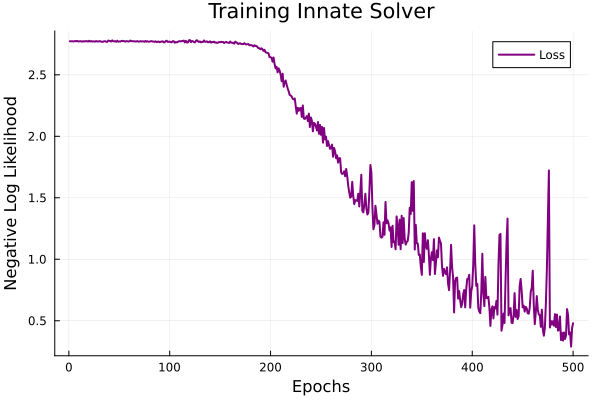

In [13]:
if TRAIN_MODEL
    losses = train_innate_solver()
    display(plot(losses, 
        label="Loss", 
        title="Training Innate Solver", 
        xlabel="Epochs", 
        ylabel="Negative Log Likelihood",
        linewidth=2, color=:purple
    ))
elseif isfile(PARAMS_FILE)
    losses = load_nn_params()
    println("Skipped training, loaded saved parameters.")
    display(plot(losses, 
        label="Loss", 
        title="Training Innate Solver", 
        xlabel="Epochs", 
        ylabel="Negative Log Likelihood",
        linewidth=2, color=:purple
    ))
else
    error("No saved model found. Set TRAIN=true to train the model first.")
end

# Inference Step: Neuro-Symbolic Integration

We now combine the Generative Model and the Neural Network using **Sequential Monte Carlo (SMC)**.

1.  **Helpers**: Functions to integrate raw integer IDs and Gen's `choicemap` constraints.
2.  **`nn_proposal`**: This is the key point. Instead of proposing grammar hypotheses blindly from the prior, we use the trained Neural Network to propose likely parameters given the observed sentences. This "guides" the particle filter toward high-probability regions much faster than random sampling.

In [14]:
function make_constraints(theta::NamedTuple)
    constraints = Gen.choicemap()
    constraints[:hd] = theta.hd
    constraints[:sd] = theta.sd
    constraints[:ao] = theta.ao
    constraints[:wh] = theta.wh
    return constraints
end

function make_token_obs_upto(trace, up_to_sentence::Int)
    obs = Gen.choicemap()
    for i in 1:up_to_sentence
        for j in 1:MAX_SENT_LEN
            val = trace[:corpus => i => (:token, j)]
            obs[:corpus => i => (:token, j)] = val
        end
    end
    return obs
end

function make_token_obs_for_sentence(trace, sentence_idx::Int)
    obs = Gen.choicemap()
    for j in 1:MAX_SENT_LEN
        val = trace[:corpus => sentence_idx => (:token, j)]
        obs[:corpus => sentence_idx => (:token, j)] = val
    end
    return obs
end

make_token_obs_for_sentence (generic function with 1 method)

### The Neural Proposal Distribution

This is the core of the **Neuro-Symbolic** interface. Instead of sampling parameters from a uniform prior (Naive), we use the trained `innate_solver` to define a Beta distribution over the parameters.

* **Input:** The encoded sentences observed so far.
* **Smoothing:** We mix the NN's prediction with a uniform distribution (epsilon-smoothing). This prevents the particle filter from becoming too confident too early and ruling out the truth due to a single bad prediction.
* **Mechanism:** The function outputs a *proposal trace* containing the four binary parameters, which `Gen` uses to weigh the particles.

In [15]:
@gen function nn_proposal(
    input_vec::Vector{Int}, 
    nn_params::NamedTuple, 
    concentration::Float64,
    smoothing::Float64 = 0.2
)
    # Get raw prediction from Neural Net
    nn_probs = predict_nn(input_vec, nn_params)
    
    # Extract raw probabilities
    raw_hd = nn_probs[1]
    raw_sd = nn_probs[2]
    raw_ao = nn_probs[3]
    raw_wh = nn_probs[4]

    # Apply Epsilon-Smoothing (Linear Interpolation)
    # This mixes the Neural Net's confidence (raw_hd) with a uniform prior (0.5).
    # Formula: P_target = (1 - ε) * P_NN + ε * 0.5
    # This prevents the proposal from being too overconfident (0.0 or 1.0) 
    # which would kill particles if the truth lies in the "impossible" region.
    target_hd = (1.0 - smoothing) * raw_hd + (smoothing * 0.5)
    target_sd = (1.0 - smoothing) * raw_sd + (smoothing * 0.5)
    target_ao = (1.0 - smoothing) * raw_ao + (smoothing * 0.5)
    target_wh = (1.0 - smoothing) * raw_wh + (smoothing * 0.5)

    # Clamp to ensure numerical stability for Beta distribution
    p_hd_mean = clamp(target_hd, 0.01, 0.99)
    p_sd_mean = clamp(target_sd, 0.01, 0.99)
    p_ao_mean = clamp(target_ao, 0.01, 0.99)
    p_wh_mean = clamp(target_wh, 0.01, 0.99)
    
    # Propose probabilities from Beta
    p_hd = @trace(beta(concentration * p_hd_mean, concentration * (1 - p_hd_mean)), :p_hd)
    p_sd = @trace(beta(concentration * p_sd_mean, concentration * (1 - p_sd_mean)), :p_sd)
    p_ao = @trace(beta(concentration * p_ao_mean, concentration * (1 - p_ao_mean)), :p_ao)
    p_wh = @trace(beta(concentration * p_wh_mean, concentration * (1 - p_wh_mean)), :p_wh)
    
    # Propose boolean parameters
    hd = @trace(bernoulli(p_hd), :hd)
    sd = @trace(bernoulli(p_sd), :sd)
    ao = @trace(bernoulli(p_ao), :ao)
    wh = @trace(bernoulli(p_wh), :wh)
    
    return (hd=hd, sd=sd, ao=ao, wh=wh)
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Int64}, NamedTuple, Float64, Float64], true, Union{Nothing, Some{Any}}[nothing, nothing, nothing, Some(0.2)], var"##nn_proposal#296", Bool[0, 0, 0, 0], false)

### Particle Rejuvenation (MCMC Moves)

SMC alone often suffers from **particle degeneracy**—where only a few particles carry all the weight, and the diversity of hypotheses collapses. To fix this, we apply MCMC (Metropolis-Hastings) moves to the particles after resampling.

* **Rejuvenation:** We randomly flip parameters within a particle and check if the new hypothesis explains the data better.
* **Adaptive Variance:** We adjust the aggressiveness of these moves based on the Effective Sample Size (ESS). If the particle diversity is low, we explore more aggressively.

In [16]:
function compute_adaptive_variance(ess, n_particles; σ_min=0.01, σ_max=0.5, power=1.0)
    ess_ratio = clamp(ess / n_particles, 0.0, 1.0)
    σ = σ_min + (σ_max - σ_min) * (1.0 - ess_ratio)^power
    return σ
end

compute_adaptive_variance (generic function with 1 method)

In [17]:
function rejuvenate_trace(trace, σ::Float64, num_moves::Int64)
    n_accepted = 0
    args = Gen.get_args(trace)
    n_sentences = args[1]
    noise_enabled = args[2] 
    
    bool_params = [:hd, :sd, :ao, :wh]
    
    for _ in 1:num_moves
        old_score = Gen.get_score(trace)
        
        # Pick random parameter to flip
        idx = rand(1:4)
        flip_bool = bool_params[idx]
        
        old_bool = trace[flip_bool]
        new_bool = !old_bool
        
        constraints = Gen.choicemap()
        
        # Constraint Generation Loop
        # We constrain the parameters we want to KEEP to their old values.
        # We constrain the parameter we want to FLIP to its new value.
        for bp in bool_params
            if bp == flip_bool
                constraints[bp] = new_bool
            else
                constraints[bp] = trace[bp]
            end
        end
        
        # We must also constrain all downstream choices (words, structure).
        # If we don't, Gen will resample them from the prior, effectively 
        # generating a brand new random sentence rather than assessing 
        # if the current sentence fits the new grammar.
        trace_choices = Gen.get_choices(trace)
        
        for i in 1:n_sentences
            # Structural & Slip choices
            constraints[:corpus => i => :is_embedded] = trace[:corpus => i => :is_embedded]
            constraints[:corpus => i => :utt_type] = trace[:corpus => i => :utt_type]
            
            if noise_enabled
                if Gen.has_value(trace_choices, :corpus => i => :ao_slip)
                    constraints[:corpus => i => :ao_slip] = trace[:corpus => i => :ao_slip]
                end
                if Gen.has_value(trace_choices, :corpus => i => :hd_slip)
                    constraints[:corpus => i => :hd_slip] = trace[:corpus => i => :hd_slip]
                end
                if Gen.has_value(trace_choices, :corpus => i => :sd_slip)
                    constraints[:corpus => i => :sd_slip] = trace[:corpus => i => :sd_slip]
                end
                if Gen.has_value(trace_choices, :corpus => i => :wh_slip)
                    constraints[:corpus => i => :wh_slip] = trace[:corpus => i => :wh_slip]
                end
            end

            # Lexical items
            constraints[:corpus => i => :subj] = trace[:corpus => i => :subj]
            constraints[:corpus => i => :obj] = trace[:corpus => i => :obj]
            constraints[:corpus => i => :adj] = trace[:corpus => i => :adj]
            
            # Verbs
            utt_type = trace[:corpus => i => :utt_type]
            if utt_type == 1 || utt_type == 3
                constraints[:corpus => i => :v_trans] = trace[:corpus => i => :v_trans]
            else
                constraints[:corpus => i => :v_intr] = trace[:corpus => i => :v_intr]
            end
            
            # Relative Clauses
            is_embedded = trace[:corpus => i => :is_embedded]
            if is_embedded
                if Gen.has_value(trace_choices, :corpus => i => :rel_verb_subj)
                    constraints[:corpus => i => :rel_verb_subj] = trace[:corpus => i => :rel_verb_subj]
                end
                if Gen.has_value(trace_choices, :corpus => i => :rel_verb_obj)
                    constraints[:corpus => i => :rel_verb_obj] = trace[:corpus => i => :rel_verb_obj]
                end
            end
            
            # Subject Drop Logic
            sd_val = constraints[:sd]
            
            if sd_val
                if Gen.has_value(trace_choices, :corpus => i => :drop_subj)
                     constraints[:corpus => i => :drop_subj] = trace[:corpus => i => :drop_subj]
                end
            end
            
            # Preserve observations
            for j in 1:MAX_SENT_LEN
                constraints[:corpus => i => (:token, j)] = trace[:corpus => i => (:token, j)]
            end
        end
        
        # Regenerate trace using the Unified Model
        new_trace, new_weight = Gen.generate(corpus_model, (n_sentences, noise_enabled), constraints)
        new_score = Gen.get_score(new_trace)
        
        log_alpha = new_score - old_score
        
        if log(rand()) < log_alpha
            trace = new_trace
            n_accepted += 1
        end
    end
    
    return trace, n_accepted / num_moves
end

function rejuvenate_particles!(
    state::Gen.ParticleFilterState;
    n_particles::Int,
    num_moves::Int = 5,
    σ_min::Float64 = 0.01,
    σ_max::Float64 = 0.5,
    power::Float64 = 1.0
)
    log_weights = Gen.get_log_weights(state)
    ess = Gen.effective_sample_size(log_weights)
    
    σ = compute_adaptive_variance(ess, n_particles; σ_min=σ_min, σ_max=σ_max, power=power)
    
    total_acceptance = 0.0
    for i in 1:length(state.traces)
        state.traces[i], acc_rate = rejuvenate_trace(state.traces[i], σ, num_moves)
        total_acceptance += acc_rate
    end
    
    avg_acceptance = total_acceptance / length(state.traces)
    
    return σ, avg_acceptance, ess
end

rejuvenate_particles! (generic function with 1 method)

In [18]:
function record_state!(history, state::Gen.ParticleFilterState)
    log_weights = Gen.get_log_weights(state)
    log_Z = Gen.logsumexp(log_weights)
    weights = exp.(log_weights .- log_Z)
    
    push!(history[:log_ml], state.log_ml_est)
    
    ess = Gen.effective_sample_size(log_weights)
    push!(history[:ess], ess)
    
    traces = Gen.get_traces(state)
    
    theta_probs = zeros(16)
    
    for (tr, w) in zip(traces, weights)
        theta = (
            hd = tr[:hd],
            sd = tr[:sd],
            ao = tr[:ao],
            wh = tr[:wh]
        )
        idx = findfirst(t -> t == theta, ALL_LANGUAGES)
        if idx !== nothing
            theta_probs[idx] += w
        end
    end
    
    push!(history[:posterior_probs], theta_probs)
    
    map_idx = argmax(theta_probs)
    push!(history[:map_estimate], ALL_LANGUAGES[map_idx])
end

record_state! (generic function with 1 method)

### Sequential Monte Carlo (SMC) Engine

This function orchestrates the learning process over time. For every new sentence:
1.  **Observe:** We condition on the new token observations.
2.  **Resample:** If the Effective Sample Size (ESS) drops below a threshold, we resample particles to focus on high-probability hypotheses.
3.  **Rejuvenate:** If we resampled, we apply the MCMC moves defined above to restore diversity.
4.  **Record:** We log the posterior probability of the 16 possible languages to track learning progress.

In [19]:
function run_smc(
    trace,
    n_sentences::Int;
    n_particles::Int = 100,
    ess_threshold::Float64 = 0.5,
    use_nn_init::Bool = false,
    input_vec::Union{Vector{Float64}, Vector{Int}, Nothing} = nothing,
    rejuv_moves::Int = 5,
    σ_min::Float64 = 0.01,
    σ_max::Float64 = 0.5,
    power::Float64 = 1.0,
    use_rejuv::Bool = true,
    always_rejuv::Bool = true,
    concentration::Float64 = 10.0,
    smoothing::Float64 = 0.25
)
    # Extract observations
    init_obs = make_token_obs_upto(trace, 1)
    
    nn_params = (
        E  = get_param(innate_solver, :E),
        W1 = get_param(innate_solver, :W1),
        b1 = get_param(innate_solver, :b1),
        W2 = get_param(innate_solver, :W2),
        b2 = get_param(innate_solver, :b2)
    )
    
    # Initialize particle filter
    if use_nn_init && input_vec !== nothing
        # Pass smoothing to the proposal args
        state = Gen.initialize_particle_filter(
            corpus_model, (1, false), init_obs, nn_proposal, 
            (input_vec, nn_params, concentration, smoothing), 
            n_particles
        )
    else
        state = state = Gen.initialize_particle_filter(corpus_model, (1, false), init_obs, n_particles)
    end
    
    history = Dict(
        :map_estimate => NamedTuple[],
        :posterior_probs => Vector{Float64}[], 
        :ess => Float64[],
        :resampled => Bool[],
        :log_ml => Float64[],
        :rejuv_σ => Float64[],
        :rejuv_acceptance => Float64[]
    )
    
    record_state!(history, state)
    
    for t in 2:n_sentences
        new_obs = make_token_obs_for_sentence(trace, t)
        
        Gen.particle_filter_step!(
            state, (t,false), (UnknownChange(),), new_obs                     
        )
        
        did_resample = Gen.maybe_resample!(state, ess_threshold=ess_threshold * n_particles)
        push!(history[:resampled], did_resample)
        
        if use_rejuv && (always_rejuv || did_resample)
            σ_used, avg_acceptance, _ = rejuvenate_particles!(
                state;
                n_particles=n_particles,
                num_moves=rejuv_moves,
                σ_min=σ_min,
                σ_max=σ_max,
                power=power
            )
            push!(history[:rejuv_σ], σ_used)
            push!(history[:rejuv_acceptance], avg_acceptance)
        else
            push!(history[:rejuv_σ], 0.0)
            push!(history[:rejuv_acceptance], 0.0)
        end
        
        record_state!(history, state)
    end
    
    return history
end

run_smc (generic function with 1 method)

### Simulation: Naive vs. Guided Learning

To quantify the benefit of the Innate Solver, we run a "Twin Simulation":
1.  **Ground Truth:** We fix a specific grammar $\theta$ and generate a corpus.
2.  **Naive Learner:** Runs SMC using only the uniform prior.
3.  **Guided Learner:** Runs SMC using the `innate_solver` to propose parameters.

We track the **Posterior Probability of the True Grammar** over time for both learners to measure convergence speed.

In [20]:
function run_trial_smc(
    theta::NamedTuple; 
    n_sentences::Int = NUM_SENTS_TRAIN,
    n_particles::Int = 100,
    rejuv_moves::Int = 5,
    σ_min::Float64 = 0.01,
    σ_max::Float64 = 0.5,
    power::Float64 = 1.0,
    concentration::Float64 = 10.0,
    smoothing::Float64 = 0.25
)
    trace, _ = Gen.generate(corpus_model, (n_sentences, false), make_constraints(theta))
    
    sentences = Gen.get_retval(trace)
    input_vec = encode_corpus(sentences, n_sentences)

    # Naive SMC
    naive_history = run_smc(
        trace, n_sentences; 
        n_particles=n_particles, 
        use_nn_init=false,
        use_rejuv=true
    )
    
    GC.gc()
    
    # Guided SMC
    guided_history = run_smc(
        trace, n_sentences; 
        n_particles=n_particles, 
        use_nn_init=true, 
        input_vec=input_vec,
        use_rejuv=true,
        rejuv_moves=rejuv_moves,
        σ_min=σ_min,
        σ_max=σ_max,
        power=power,
        concentration=concentration,
        smoothing=smoothing
    )
    
    trace = nothing
    GC.gc()
    
    # NN Predictions
    nn_params = (
        E  = get_param(innate_solver, :E),
        W1 = get_param(innate_solver, :W1),
        b1 = get_param(innate_solver, :b1),
        W2 = get_param(innate_solver, :W2),
        b2 = get_param(innate_solver, :b2)
    )
    nn_probs = predict_nn(input_vec, nn_params)
    nn_preds = (
        hd = nn_probs[1] > 0.5,
        sd = nn_probs[2] > 0.5,
        ao = nn_probs[3] > 0.5,
        wh = nn_probs[4] > 0.5,
    )
    
    nn_correct = (nn_preds.hd == theta.hd && nn_preds.sd == theta.sd &&
                  nn_preds.ao == theta.ao && nn_preds.wh == theta.wh)
    
    return (
        theta = theta,
        n_sentences = n_sentences,
        naive_history = naive_history,
        guided_history = guided_history,
        nn_correct = nn_correct,
        nn_probs = nn_probs,
        nn_preds = nn_preds,
        sentences_ids = sentences
    )
end

run_trial_smc (generic function with 1 method)

### Performance Metrics

We calculate several metrics to analyze the results:
* **AUC (Area Under Curve):** The aggregate probability mass assigned to the correct grammar over the entire simulation. Higher is better.
* **Time to Convergence:** How many sentences it took for the learner to reach 50% and 90% confidence in the correct grammar.
* **MAP Accuracy:** Whether the Maximum A Posteriori estimate matches the ground truth at the end of the run.

In [21]:
function compute_smc_metrics(history, target::NamedTuple, n_sentences::Int)
    posterior_probs = history[:posterior_probs]
    map_estimates = history[:map_estimate]
    ess_history = history[:ess]
    
    # Convergence metrics
    correct = [est == target for est in map_estimates]
    ever_converged = any(correct)
    first_correct = findfirst(correct)
    final_correct = correct[end]
    
    # Target probability over time
    all_thetas = all_language_types()
    target_idx = findfirst(t -> t == target, all_thetas)
    target_prob_history = [probs[target_idx] for probs in posterior_probs]
    
    # Area under curve
    auc = sum(target_prob_history) / n_sentences
    
    # Threshold crossings
    idx_50 = findfirst(p -> p >= 0.5, target_prob_history)
    sentences_to_50 = idx_50 === nothing ? Inf : idx_50
    idx_90 = findfirst(p -> p >= 0.9, target_prob_history)
    sentences_to_90 = idx_90 === nothing ? Inf : idx_90
    
    max_prob_history = [maximum(probs) for probs in posterior_probs]
    
    return (
        ever_converged = ever_converged,
        first_correct = first_correct,
        final_correct = final_correct,
        final_target_prob = target_prob_history[end],
        target_prob_history = target_prob_history,
        posterior_probs = posterior_probs,
        ess = ess_history,                
        auc = auc,
        sentences_to_50 = sentences_to_50,
        sentences_to_90 = sentences_to_90,
        max_prob_history = max_prob_history
    )
end

compute_smc_metrics (generic function with 1 method)

In [22]:
function process_raw_trials(raw_trials)
    processed = []
    for t in raw_trials
        naive_metrics = compute_smc_metrics(t.naive_history, t.theta, t.n_sentences)
        guided_metrics = compute_smc_metrics(t.guided_history, t.theta, t.n_sentences)
        
        push!(processed, (
            naive_metrics = naive_metrics,
            guided_metrics = guided_metrics,
            nn_correct = t.nn_correct,
            nn_probs = t.nn_probs,
            nn_preds = t.nn_preds,
            theta = t.theta,
            sentences_ids = t.sentences_ids
        ))
    end
    return processed
end

function save_raw_trials(filename::String, raw_trials)
    @save filename raw_trials
    println("Saved $(length(raw_trials)) trials to $filename")
end

function load_and_process_trials(filename::String)
    @load filename raw_trials
    println("Loaded $(length(raw_trials)) raw trials from $filename")
    
    processed = process_raw_trials(raw_trials)
    println("Processed into analysis-ready format")
    
    return processed
end

load_and_process_trials (generic function with 1 method)

In [23]:
RUN_SMC = true
SMC_FILE = "smc_results_rejuv.jld2"

if RUN_SMC
    raw_trials = []
    all_thetas = all_language_types()
    
    for (theta_idx, theta) in enumerate(all_thetas)
        for i in 1:5
            println("Theta $theta_idx/16, Iteration $i/5: theta=$theta")
            flush(stdout)
            
            try

                result = run_trial_smc(
                    theta; 
                    n_sentences=30,      
                    n_particles=100,     
                    rejuv_moves=10,      
                    σ_min=0.05,          
                    σ_max=0.5,           
                    smoothing=0.2       
                )
                push!(raw_trials, result)
            catch e
                println("ERROR at theta=$theta, iter=$i: $e")
            end
            GC.gc()
        end
        save_raw_trials(SMC_FILE, raw_trials)
        GC.gc()
    end
    
    all_trials = process_raw_trials(raw_trials)
    println("Simulation complete. Processed $(length(all_trials)) trials.")

else
    if isfile(SMC_FILE)
        all_trials = load_and_process_trials(SMC_FILE)
    else
        error("File $SMC_FILE not found. Set RUN_SMC=true to generate it.")
    end
end

Theta 1/16, Iteration 1/5: theta=(hd = false, sd = false, ao = false, wh = false)
Theta 1/16, Iteration 2/5: theta=(hd = false, sd = false, ao = false, wh = false)
Theta 1/16, Iteration 3/5: theta=(hd = false, sd = false, ao = false, wh = false)
Theta 1/16, Iteration 4/5: theta=(hd = false, sd = false, ao = false, wh = false)
Theta 1/16, Iteration 5/5: theta=(hd = false, sd = false, ao = false, wh = false)
Saved 5 trials to smc_results_rejuv.jld2
Theta 2/16, Iteration 1/5: theta=(hd = false, sd = false, ao = false, wh = true)
Theta 2/16, Iteration 2/5: theta=(hd = false, sd = false, ao = false, wh = true)
Theta 2/16, Iteration 3/5: theta=(hd = false, sd = false, ao = false, wh = true)
Theta 2/16, Iteration 4/5: theta=(hd = false, sd = false, ao = false, wh = true)
Theta 2/16, Iteration 5/5: theta=(hd = false, sd = false, ao = false, wh = true)
Saved 10 trials to smc_results_rejuv.jld2
Theta 3/16, Iteration 1/5: theta=(hd = false, sd = false, ao = true, wh = false)
Theta 3/16, Iteration

# Visualization and Analysis

Finally, we visualize the learning trajectories. The dashboard below plots:

1.  **Global Performance**:
    * **Learning Curves**: Average probability of the correct grammar over time.
    * **Convergence Speed**: The fraction of trials that reached >50% confidence at each time step.
    * **Summary Statistics**: Key metrics like AUC (area under curve) improvement and final accuracy.
2.  **Neural Network Diagnostics**:
    * **Per-Parameter Accuracy**: How well the NN predicts specific parameters (e.g., Head Direction).
    * **Parameter Learnability**: Which parameters are inherently harder for the system to learn.
3.  **Linguistic Analysis**:
    * **Language Difficulty**: Performance breakdown by specific language types (e.g., "VO-Drop-AN-Front").
    * **Typology**: A comparison of learning trajectories for "Natural" (attested) vs. "Rare" (unattested) language patterns.

In [24]:
function get_confidence(pred_prob, true_val)
    return true_val ? pred_prob : (1.0 - pred_prob)
end

function compute_nn_metrics(trials)
    hd_conf = mean([get_confidence(t.nn_probs[1], t.theta.hd) for t in trials])
    sd_conf = mean([get_confidence(t.nn_probs[2], t.theta.sd) for t in trials])
    ao_conf = mean([get_confidence(t.nn_probs[3], t.theta.ao) for t in trials])
    wh_conf = mean([get_confidence(t.nn_probs[4], t.theta.wh) for t in trials])
    
    exact_match = mean([t.nn_correct for t in trials])
    
    hamming_acc = mean([
        sum([
            t.nn_preds.hd == t.theta.hd,
            t.nn_preds.sd == t.theta.sd,
            t.nn_preds.ao == t.theta.ao,
            t.nn_preds.wh == t.theta.wh
        ]) / 4.0
        for t in trials
    ])
    
    return (
        per_param_conf = (hd=hd_conf, sd=sd_conf, ao=ao_conf, wh=wh_conf),
        mean_param = mean([hd_conf, sd_conf, ao_conf, wh_conf]),
        exact_match = exact_match,
        hamming = hamming_acc
    )
end

function get_marginal_param_probs(grammar_probs::Vector{Float64}, target_theta::NamedTuple)
    p_hd = 0.0; p_sd = 0.0; p_ao = 0.0; p_wh = 0.0
    
    for (i, g) in enumerate(ALL_LANGUAGES)
        if g.hd == target_theta.hd p_hd += grammar_probs[i] end
        if g.sd == target_theta.sd p_sd += grammar_probs[i] end
        if g.ao == target_theta.ao p_ao += grammar_probs[i] end
        if g.wh == target_theta.wh p_wh += grammar_probs[i] end
    end
    return (hd=p_hd, sd=p_sd, ao=p_ao, wh=p_wh)
end

function get_learning_curves_plot(all_trials, n_sentences)
    n_trials = length(all_trials)
    naive_curves = [t.naive_metrics.target_prob_history for t in all_trials]
    guided_curves = [t.guided_metrics.target_prob_history for t in all_trials]
    
    avg_naive = [mean([c[i] for c in naive_curves]) for i in 1:n_sentences]
    avg_guided = [mean([c[i] for c in guided_curves]) for i in 1:n_sentences]
    
    p = plot(1:n_sentences, avg_naive, label="Naive", 
             linewidth=2, color=:indianred, ribbon=std.([[c[i] for c in naive_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p, 1:n_sentences, avg_guided, label="Guided", 
          linewidth=2, color=:steelblue, ribbon=std.([[c[i] for c in guided_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p, xlabel="Sentences", ylabel="P(correct)", title="Overall Learning Curves", legend=:bottomright)
    return p
end

function get_survival_plot(all_trials, n_sentences)
    naive_survival = [mean([t.naive_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    guided_survival = [mean([t.guided_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    
    p = plot(1:n_sentences, naive_survival, label="Naive", linewidth=2, color=:indianred)
    plot!(p, 1:n_sentences, guided_survival, label="Guided", linewidth=2, color=:steelblue)
    plot!(p, xlabel="Sentences", ylabel="Fraction > 50%", title="Convergence Speed", legend=:bottomright)
    return p
end

function get_entropy_plot(all_trials, n_sentences)
    n_steps = length(all_trials[1].guided_metrics.target_prob_history)
    
    function calc_entropy(probs)
        s = 0.0
        for p in probs
            if p > 1e-10
                s -= p * log2(p)
            end
        end
        return s
    end

    avg_entropy_naive = zeros(n_steps)
    avg_entropy_guided = zeros(n_steps)
    
    for t in all_trials
        for (i, p) in enumerate(t.naive_metrics.posterior_probs)
            if i <= n_steps avg_entropy_naive[i] += calc_entropy(p) end
        end
        for (i, p) in enumerate(t.guided_metrics.posterior_probs)
            if i <= n_steps avg_entropy_guided[i] += calc_entropy(p) end
        end
    end
    
    n = length(all_trials)
    p = plot(1:n_steps, avg_entropy_naive ./ n, label="Naive", color=:indianred, lw=2)
    plot!(p, 1:n_steps, avg_entropy_guided ./ n, label="Guided", color=:steelblue, lw=2)
    
    plot!(p, xlabel="Sentences", ylabel="Entropy (Bits)", 
          title="Uncertainty Reduction", legend=:topright)
    return p
end

function get_param_trajectory_plot(all_trials, n_sentences)
    n_steps = length(all_trials[1].guided_metrics.target_prob_history)
    sum_hd = zeros(n_steps); sum_sd = zeros(n_steps)
    sum_ao = zeros(n_steps); sum_wh = zeros(n_steps)
    
    for t in all_trials
        for (step, probs) in enumerate(t.guided_metrics.posterior_probs)
            if step > n_steps break end
            marginals = get_marginal_param_probs(probs, t.theta)
            sum_hd[step] += marginals.hd
            sum_sd[step] += marginals.sd
            sum_ao[step] += marginals.ao
            sum_wh[step] += marginals.wh
        end
    end
    
    n = length(all_trials)
    p = plot(1:n_steps, sum_hd ./ n, label="Head Dir", lw=2, linestyle=:solid)
    plot!(p, 1:n_steps, sum_ao ./ n, label="Adj Order", lw=2, linestyle=:dash)
    plot!(p, 1:n_steps, sum_sd ./ n, label="Subj Drop", lw=2, linestyle=:dot)
    plot!(p, 1:n_steps, sum_wh ./ n, label="Wh-Front", lw=2, linestyle=:dashdot)
    
    plot!(p, xlabel="Sentences", ylabel="P(Correct Parameter)", 
          title="Parameter Learning Rates", legend=:bottomright, ylim=(0, 1.05))
    return p
end

function get_nn_accuracy_bar_plot(nn_metrics)
    param_labels = ["Head\nDir", "Subj\nDrop", "Adj\nOrder", "Wh-\nFront"]
    
    param_confs = [
        nn_metrics.per_param_conf.hd, 
        nn_metrics.per_param_conf.sd, 
        nn_metrics.per_param_conf.ao, 
        nn_metrics.per_param_conf.wh
    ]
    
    p = bar(param_labels, param_confs, title="NN Posterior Confidence",
            ylabel="P(True Parameter)", legend=false, color=:steelblue, fillalpha=0.7, ylim=(0,1.05))
    hline!(p, [0.5], linestyle=:dash, color=:red, label="Chance")
    return p
end

function get_language_difficulty_plot(all_trials)
    trials_by_lang = Dict()
    for t in all_trials
        key = (t.theta.hd, t.theta.sd, t.theta.ao, t.theta.wh)
        if !haskey(trials_by_lang, key) trials_by_lang[key] = [] end
        push!(trials_by_lang[key], t)
    end
    
    labels = String[]
    metric = Float64[] 
    
    for (theta, trials) in trials_by_lang
        l = (theta[1] ? "VO" : "OV") * (theta[2] ? "-Drop" : "-Keep")
        avg_auc = mean([t.guided_metrics.auc for t in trials])
        
        push!(labels, l)
        push!(metric, avg_auc)
    end
    
    order = sortperm(metric)
    
    p = bar(labels[order], metric[order], orientation=:v, xrotation=45,
            title="Language Difficulty (Learning Speed)", 
            ylabel="Avg Confidence (AUC)", 
            legend=false, color=:steelblue, ylim=(0, 1.05))
    return p
end

function get_convergence_speed_plot(all_trials, n_sentences)
    trials_by_lang = Dict()
    for t in all_trials
        key = (t.theta.hd, t.theta.sd, t.theta.ao, t.theta.wh)
        if !haskey(trials_by_lang, key) trials_by_lang[key] = [] end
        push!(trials_by_lang[key], t)
    end
    
    labels = String[]
    naive_speed = Float64[]
    guided_speed = Float64[]
    
    for (theta, trials) in trials_by_lang
        l = (theta[1] ? "VO" : "OV") * (theta[2] ? "D" : "K") * (theta[3] ? "A" : "N") * (theta[4] ? "F" : "S")
        push!(labels, l)
        push!(naive_speed, mean([min(t.naive_metrics.sentences_to_90, n_sentences) for t in trials]))
        push!(guided_speed, mean([min(t.guided_metrics.sentences_to_90, n_sentences) for t in trials]))
    end
    
    order = sortperm(guided_speed)
    
    p = groupedbar(labels[order], hcat(naive_speed[order], guided_speed[order]),
                   label=["Naive" "Guided"], title="Sentences to 90% Conf.",
                   xrotation=45, color=[:indianred :steelblue], legend=:topleft)
    return p
end

function get_typology_curve_plot(all_trials, n_sentences)
    natural_patterns = [
        (hd=true, sd=false, ao=true, wh=true), (hd=false, sd=true, ao=false, wh=false),
        (hd=true, sd=true, ao=false, wh=true), (hd=false, sd=false, ao=false, wh=false)
    ]
    natural_trials = [t for t in all_trials if t.theta in natural_patterns]
    rare_trials = [t for t in all_trials if !(t.theta in natural_patterns)]
    
    nat_curves = [t.guided_metrics.target_prob_history for t in natural_trials]
    rare_curves = [t.guided_metrics.target_prob_history for t in rare_trials]
    
    avg_nat = [mean([c[i] for c in nat_curves]) for i in 1:n_sentences]
    avg_rare = [mean([c[i] for c in rare_curves]) for i in 1:n_sentences]
    
    p = plot(1:n_sentences, avg_nat, label="Natural", linewidth=3, color=:forestgreen)
    plot!(p, 1:n_sentences, avg_rare, label="Rare", linewidth=3, color=:darkorange)
    plot!(p, xlabel="Sentences", ylabel="P(correct)", title="Typology: Learning Curves", legend=:bottomright)
    return p
end

function get_typology_bar_plot(all_trials)
    natural_patterns = [
        (hd=true, sd=false, ao=true, wh=true),   # English
        (hd=false, sd=true, ao=false, wh=false), # Japanese
        (hd=true, sd=true, ao=false, wh=true),   # Spanish
        (hd=false, sd=false, ao=false, wh=false), # German-ish
    ]
    natural_trials = [t for t in all_trials if t.theta in natural_patterns]
    rare_trials = [t for t in all_trials if !(t.theta in natural_patterns)]
    
    nat_acc = mean([t.guided_metrics.final_target_prob for t in natural_trials])
    rare_acc = mean([t.guided_metrics.final_target_prob for t in rare_trials])
    
    p = bar(["Natural", "Rare"], [nat_acc, rare_acc], 
            title="Natural vs Rare", color=[:forestgreen, :darkorange], legend=false, ylim=(0,1))
    return p
end

function get_param_difficulty_summary_plot(all_trials)
    params = [:hd, :sd, :ao, :wh]
    param_names = ["HD", "SD", "AO", "Wh"]
    
    vals_true = Float64[]
    vals_false = Float64[]
    
    for param in params
        true_trials = [t for t in all_trials if getfield(t.theta, param) == true]
        false_trials = [t for t in all_trials if getfield(t.theta, param) == false]
        push!(vals_true, mean([t.guided_metrics.final_target_prob for t in true_trials]))
        push!(vals_false, mean([t.guided_metrics.final_target_prob for t in false_trials]))
    end
    
    p = groupedbar(param_names, hcat(vals_false, vals_true), 
        label=["Param=False" "Param=True"], title="Param Learnability", 
        color=[:indianred :steelblue], legend=:bottomright, ylim=(0,1))
    return p
end

function get_combined_stats_text_plot(all_trials, nn_metrics)
    naive_auc = mean([t.naive_metrics.auc for t in all_trials])
    guided_auc = mean([t.guided_metrics.auc for t in all_trials])
    naive_final = mean([t.naive_metrics.final_target_prob for t in all_trials])
    guided_final = mean([t.guided_metrics.final_target_prob for t in all_trials])
    
    p = plot(axis=false, grid=false, ticks=false, xlim=(0,1), ylim=(0,1))
    
    annotate!(p, 0.5, 0.95, text("SMC METRICS", :center, 11))
    annotate!(p, 0.1, 0.85, text("Naive Final P:", :left, 9))
    annotate!(p, 0.9, 0.85, text("$(round(naive_final*100, digits=1))%", :right, :indianred, 9))
    annotate!(p, 0.1, 0.75, text("Guided Final P:", :left, 9))
    annotate!(p, 0.9, 0.75, text("$(round(guided_final*100, digits=1))%", :right, :steelblue, 9))
    
    imp = (guided_auc - naive_auc)/naive_auc * 100
    annotate!(p, 0.5, 0.65, text("AUC Improvement: +$(round(imp, digits=1))%", :center, 9))
    
    annotate!(p, 0.5, 0.55, text("─"^40, :center, 10))
    
    annotate!(p, 0.5, 0.45, text("NN DIAGNOSTICS", :center, 11))
    annotate!(p, 0.1, 0.35, text("Exact Match:", :left, 9))
    annotate!(p, 0.9, 0.35, text("$(round(nn_metrics.exact_match*100, digits=1))%", :right, 9))
    annotate!(p, 0.1, 0.25, text("Hamming Acc:", :left, 9))
    annotate!(p, 0.9, 0.25, text("$(round(nn_metrics.hamming*100, digits=1))%", :right, 9))
    
    return p
end

get_combined_stats_text_plot (generic function with 1 method)

1. Overall Learning Curves


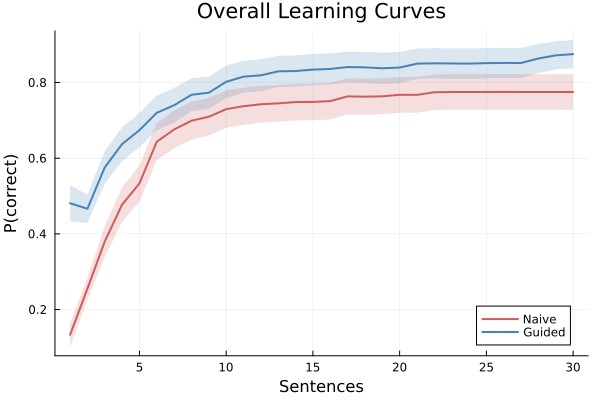

2. Convergence Speed (Fraction > 50%)


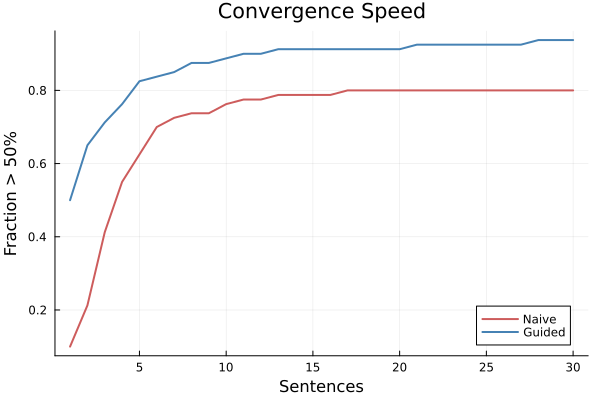

3. Uncertainty Reduction (Entropy)


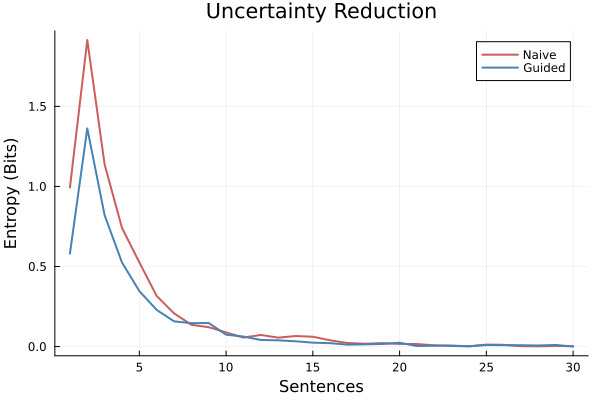

4. Parameter Learning Rates


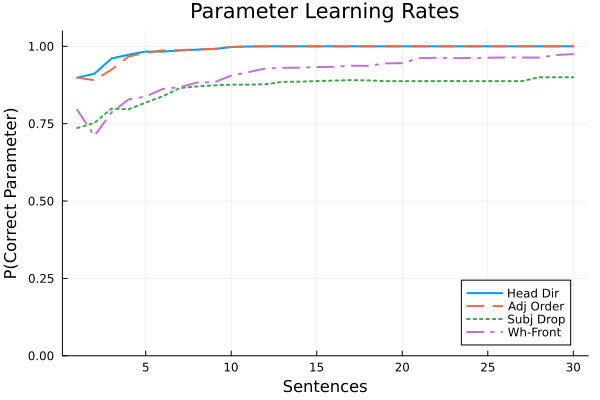

6. SMC vs NN Summary Stats


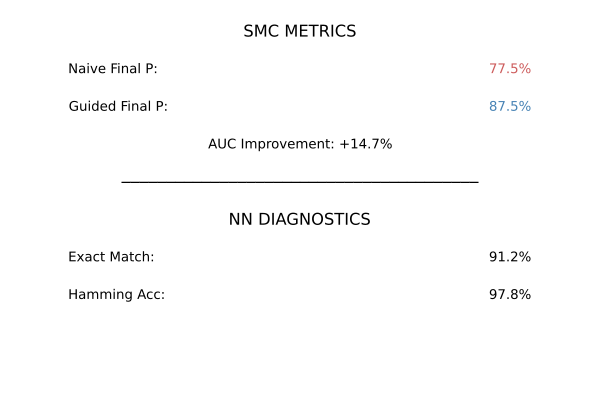

7. Neural Network Accuracy


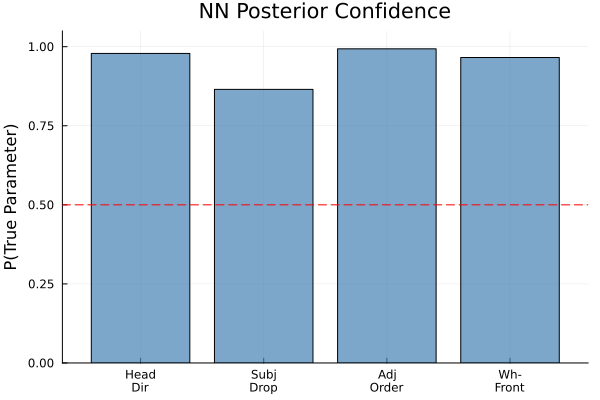

8. Difficulty by Parameter Type


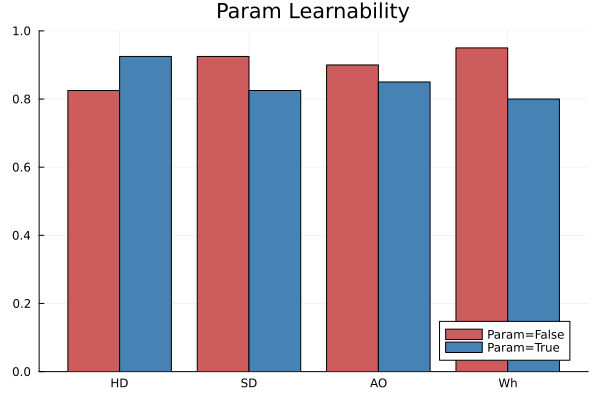

9. Convergence Speed by Language Type


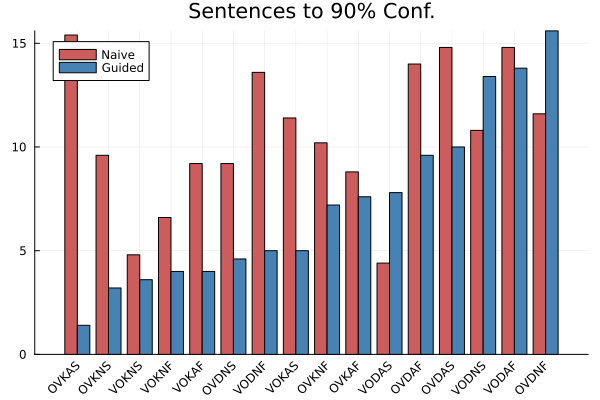

10. Difficulty by Language (Bar)


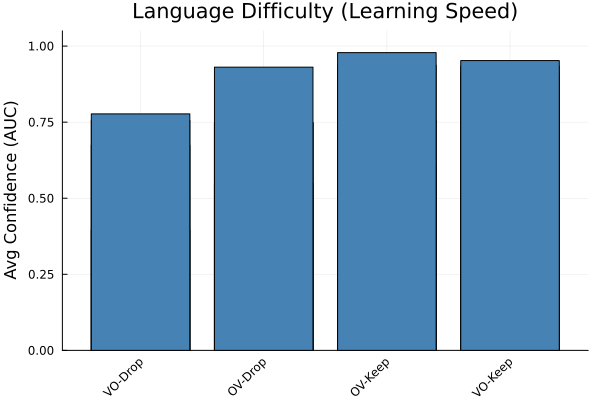

11. Natural vs Rare (Curves)


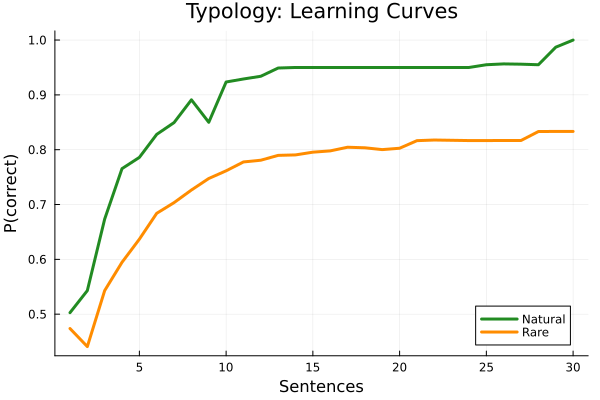

12. Natural vs Rare (Final Accuracy)


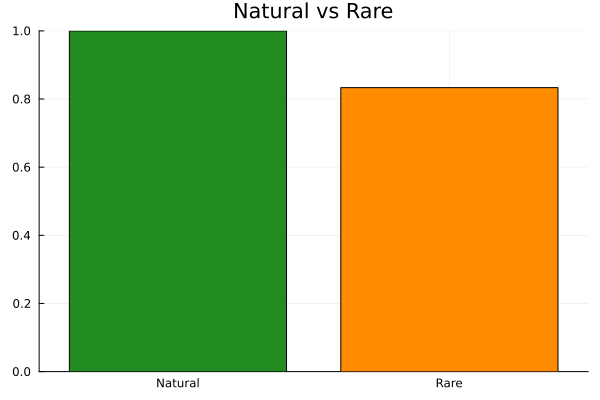

In [25]:
n_sentences = length(all_trials[1].naive_metrics.target_prob_history)
nn_metrics = compute_nn_metrics(all_trials)

println("1. Overall Learning Curves")
p1 = get_learning_curves_plot(all_trials, n_sentences)
display(p1)

println("2. Convergence Speed (Fraction > 50%)")
p2 = get_survival_plot(all_trials, n_sentences)
display(p2)

println("3. Uncertainty Reduction (Entropy)")
p3 = get_entropy_plot(all_trials, n_sentences)
display(p3)

println("4. Parameter Learning Rates")
p4 = get_param_trajectory_plot(all_trials, n_sentences)
display(p4)

println("6. SMC vs NN Summary Stats")
p6 = get_combined_stats_text_plot(all_trials, nn_metrics)
display(p6)

println("7. Neural Network Accuracy")
p7 = get_nn_accuracy_bar_plot(nn_metrics)
display(p7)

println("8. Difficulty by Parameter Type")
p8 = get_param_difficulty_summary_plot(all_trials)
display(p8)

println("9. Convergence Speed by Language Type")
p9 = get_convergence_speed_plot(all_trials, n_sentences)
display(p9)

println("10. Difficulty by Language (Bar)")
p10 = get_language_difficulty_plot(all_trials)
display(p10)

println("11. Natural vs Rare (Curves)")
p11 = get_typology_curve_plot(all_trials, n_sentences)
display(p11)

println("12. Natural vs Rare (Final Accuracy)")
p12 = get_typology_bar_plot(all_trials)
display(p12)